In [1]:
# =============================================================================
# 1: DRIVE MOUNT
# =============================================================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [20]:
# =============================================================================
# 2: POSITIVE SAMPLE EXTRACTION (MINING SITES)
# =============================================================================
#
# WARNING: This notebook is for educational purposes only.
# Running it will attempt to mount YOUR Google Drive, not the author's.
#
# PURPOSE:
# This cell automates the extraction of 256x256 image patches centered on known
# mining sites. It utilizes the centroid-float logic to ensure each patch is
# geographically centered on the mining activity defined in the training asset.
#
# The script assembles an 8-band stack:
#   - Sentinel-2 (Blue, Green, Red, NIR)
#   - NDVI (Normalized Difference Vegetation Index)
#   - Sentinel-1 SAR (VV, VH backscatter)
#   - Binary Label (1.0 for Mining)
#
# This directly supports:
#   - Capstone Objective: Develop and apply a CNN-based computer-vision model in GEE
#   - Hypothesis H1: Achieve 80–90% overall accuracy in identifying mining deforestation
#
# GOAL:
# Generate a high-quality positive training dataset for the U-Net model,
# ensuring consistent resolution (5m) and band alignment across all samples.
#
# IMPORTANT EDUCATIONAL DISCLAIMERS:
# - This code is developed strictly for academic purposes as part of the Master of Science
#   in Geographic Information Systems (GIS) Capstone project (430.800) at Johns Hopkins University.
# - All models, code, and results are for educational, research, and demonstration purposes only.
# - This work is NOT intended for operational use, law enforcement, or real-world decision-making.
# - Outputs should not be used to identify or accuse any specific illegal activities without
#   proper authorization and coordination with Brazilian authorities.
# - Users must comply with all data provider terms (ESA Sentinel data) and local regulations.
# - The model and results are provided "as-is" with no warranty for any purpose beyond academic study.
#
# AI DISCLOSURE:
# AI was used to augment the development of this extraction logic, specifically
# in the optimization of the Sentinel-1 "Safe Radar" masking functions and the
# reproducible indexing strategy for Earth Engine batch exports.
#
# Author: ATD
# Program: Johns Hopkins University - MS in Geographic Information Systems
# Capstone Course: 430.800
# Date: April 2026
# =============================================================================

import ee
import time
from google.colab import auth

# 1. INITIALIZATION & AUTHENTICATION - CREATE (POS)
auth.authenticate_user()
ee.Initialize(project='trusty-hub-437505-e5')

# --- DATA DEFINITIONS ---
ASSET_PATH = 'projects/trusty-hub-437505-e5/assets/mining_cumulative_2018_2024'
mining_fc = ee.FeatureCollection(ASSET_PATH)

# --- INDEX & BATCH CONFIGURATION ---
START_IDX = 1300
COUNT = 200
POS_FOLDER = 'Mining_Auto_Gold_5m_v1'

def get_safe_radar(img):
    """Sentinel-1 (Radar) with Universal-Band Safety and Artifact Masking"""
    # FIX: Use .And() [Capital A] or & for ee.Image logical operations
    edge_mask = img.select(0).gt(-30).And(img.select(1).gt(-30))
    img = img.updateMask(edge_mask)

    available = img.bandNames()
    # Use EE logic to pick bands
    b1 = ee.Algorithms.If(available.contains('VV'), 'VV', 'HH')
    b2 = ee.Algorithms.If(available.contains('VH'), 'VH', 'HV')

    return img.select([b1, b2]).rename(['VV', 'VH']).float().unmask(-15)

# --- SECTION: POSITIVE MINING SAMPLES ---
print(f"🚀 Launching POSITIVE Batch: {START_IDX} to {START_IDX + COUNT - 1}")

# Create the label mask (1 for Mining)
mining_mask = ee.Image.constant(1).float().clip(mining_fc).unmask(0).rename('label')

# Sort by index to ensure reproducible sampling
gold_targets = mining_fc.sort('system:index').toList(COUNT, START_IDX)

# Get the list size to loop safely
list_size = gold_targets.size().getInfo()

for i in range(list_size):
    try:
        feat = ee.Feature(gold_targets.get(i))

        # A. Geometry Clean-up
        point_geom = feat.geometry().centroid(1)
        export_region = point_geom.buffer(640).bounds()

        # B. Sentinel-2 (Optical + NDVI)
        s2_img = ee.ImageCollection("COPERNICUS/S2_HARMONIZED") \
            .filterBounds(export_region) \
            .filterDate('2023-01-01', '2024-01-01') \
            .sort('CLOUDY_PIXEL_PERCENTAGE') \
            .first()

        s2_bands = s2_img.select(['B2', 'B3', 'B4', 'B8']).float()
        ndvi = s2_bands.normalizedDifference(['B8', 'B4']).rename('NDVI').float()

        # C. Sentinel-1 (Radar)
        s1_col = ee.ImageCollection('COPERNICUS/S1_GRD') \
            .filterBounds(export_region) \
            .filterDate('2023-01-01', '2024-01-01')

        # Handle cases with no radar coverage
        s1_bands = ee.Algorithms.If(
            s1_col.size().gt(0),
            get_safe_radar(s1_col.median()),
            ee.Image.constant([-15, -22]).rename(['VV', 'VH']).float()
        )
        s1_bands = ee.Image(s1_bands)

        # D. Assemble 8-Band Stack
        final_stack = s2_bands.addBands(ndvi).addBands(s1_bands).addBands(mining_mask).float()

        # E. Start Export
        actual_idx = i + START_IDX
        ee.batch.Export.image.toDrive(
            image=final_stack,
            description=f'8HR_Gold_{actual_idx}',
            folder=POS_FOLDER,
            fileNamePrefix=f'Auto_Gold_Patch_{actual_idx}',
            region=export_region,
            scale=5,
            fileFormat='TFRecord',
            formatOptions={'patchDimensions': [256, 256], 'compressed': True}
        ).start()

        if i % 20 == 0:
            print(f"✅ Submitted Patch {actual_idx}...")

    except Exception as e:
        print(f"Skipping index {i + START_IDX} due to error: {e}")
        continue

print(f"\n--- POSITIVE BATCH COMPLETE ---")

🚀 Launching POSITIVE Batch: 1300 to 1499
✅ Submitted Patch 1300...
✅ Submitted Patch 1320...
✅ Submitted Patch 1340...
✅ Submitted Patch 1360...
✅ Submitted Patch 1380...
✅ Submitted Patch 1400...
✅ Submitted Patch 1420...
✅ Submitted Patch 1440...
✅ Submitted Patch 1460...
✅ Submitted Patch 1480...

--- POSITIVE BATCH COMPLETE ---


In [17]:
# =============================================================================
# 3: BATCH AUDIT (UPDATED FOR FLOAT32 SCHEMA) - POSITIVE SAMPLES
# =============================================================================
#
# WARNING: This notebook is for educational purposes only.
# Running it will attempt to mount YOUR Google Drive, not the author's.
#
# PURPOSE:
# This cell performs a visual verification "audit" of the exported positive
# mining patches. It ensures the 8-band stack was correctly assembled and
# that the geographic centering (centroid float) aligned with the mining features.
#
# KEY OPERATIONS:
#   - Parse the Float32 TFRecord schema (Blue, Green, Red, VV, VH, Label).
#   - Apply 2/98 percentile normalization to reconstructed Sentinel-2 RGB images.
#   - Visualize Sentinel-1 Radar (SAR) backscatter using the 'magma' colormap.
#   - Overlay the binary mining label to verify ground-truth alignment.
#
# This directly supports:
#   - Capstone Objective: Develop and apply a CNN-based computer-vision model in GEE
#   - Hypothesis H1: Achieve 80–90% overall accuracy in identifying mining deforestation
#
# GOAL:
# Systematically confirm data integrity before training, identifying any
# cloud-obscured patches or radar artifacts that could degrade CNN performance.
#
# IMPORTANT EDUCATIONAL DISCLAIMERS:
# - This code is developed strictly for academic purposes as part of the Master of Science
#   in Geographic Information Systems (GIS) Capstone project (430.800) at Johns Hopkins University.
# - All models, code, and results are for educational, research, and demonstration purposes only.
# - This work is NOT intended for operational use, law enforcement, or real-world decision-making.
# - Outputs should not be used to identify or accuse any specific illegal activities without
#   proper authorization and coordination with Brazilian authorities.
# - Users must comply with all data provider terms (ESA Sentinel data) and local regulations.
# - The model and results are provided "as-is" with no warranty for any purpose beyond academic study.
#
# AI DISCLOSURE:
# AI was used to augment the development of this audit script, specifically
# in optimizing the percentile-based normalization math and the dynamic
# visualization layout for the multi-sensor (Optical/Radar) comparison.
#
# Author: ATD
# Program: Johns Hopkins University - MS in Geographic Information Systems
# Capstone Course: 430.800
# Date: April 2026
# =============================================================================

import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# The folder where your new 8-hour batch is landing
target_dir = '/content/drive/MyDrive/Mining_Auto_Gold_5m_v1'

# Looking at a small sample of your new 300+ batch
patch_range = range(900, 915)

# UPDATED SCHEMA: All bands are now float32 in the new batch
features = {
    'B2': tf.io.FixedLenSequenceFeature([], tf.float32, allow_missing=True),
    'B3': tf.io.FixedLenSequenceFeature([], tf.float32, allow_missing=True),
    'B4': tf.io.FixedLenSequenceFeature([], tf.float32, allow_missing=True),
    'VV': tf.io.FixedLenSequenceFeature([], tf.float32, allow_missing=True),
    'VH': tf.io.FixedLenSequenceFeature([], tf.float32, allow_missing=True),
    'label': tf.io.FixedLenSequenceFeature([], tf.float32, allow_missing=True),
}

def audit_new_batch(indices):
    for idx in indices:
        # Note: GEE exports usually append -00000 to the filename
        file_path = os.path.join(target_dir, f'Auto_Gold_Patch_{idx}-00000.tfrecord.gz')

        if not os.path.exists(file_path):
            print(f"Skipping Index {idx}: File hasn't landed in Drive yet.")
            continue

        dataset = tf.data.TFRecordDataset(file_path, compression_type='GZIP')
        for raw_record in dataset.take(1):
            try:
                ex = tf.io.parse_single_example(raw_record, features)

                # Reshape to 256x256 (no casting needed anymore!)
                r = ex['B4'].numpy().reshape(256, 256)
                g = ex['B3'].numpy().reshape(256, 256)
                b = ex['B2'].numpy().reshape(256, 256)

                # RGB Reconstruction with 2/98 percentile normalization
                rgb = np.stack([r, g, b], axis=-1)
                p2, p98 = np.percentile(rgb, (2, 98))
                rgb_norm = np.clip((rgb - p2) / (p98 - p2 + 1e-8), 0, 1)

                vv = ex['VV'].numpy().reshape(256, 256)
                mask = ex['label'].numpy().reshape(256, 256)

                # Visualization
                fig, ax = plt.subplots(1, 3, figsize=(15, 5))
                ax[0].imshow(rgb_norm)
                ax[0].set_title(f"Patch {idx}: Sentinel-2 RGB")

                ax[1].imshow(vv, cmap='magma') # Magma helps see radar texture better
                ax[1].set_title("Sentinel-1 Radar (VV)")

                ax[2].imshow(mask, cmap='Reds')
                ax[2].set_title("Mining Label (Target)")

                for a in ax: a.axis('off')
                plt.tight_layout()
                plt.show()

            except Exception as e:
                print(f"Index {idx} failed: {e}")

# Run the audit
print("Starting audit of new high-res patches...")
audit_new_batch(patch_range)

Output hidden; open in https://colab.research.google.com to view.

In [14]:
# =============================================================================
# 4: ULTIMATE DATA CLEANING & QUARANTINE (POSITIVE SAMPLES) - VERSION 5
# =============================================================================
#
# WARNING: This notebook is for educational purposes only.
# Running it will attempt to mount YOUR Google Drive, not the author's.
#
# PURPOSE:
# This is the "Surgical" version of the scrubbing routine. It goes beyond
# simple zero-checks to catch "Ghost Patches" (like Patch 914) that contain
# low-amplitude sensor noise or border artifacts. It uses Statistical Mode
# and Amplitude Variance to ensure every patch contains a real signal.
#
# KEY OPERATIONS:
#   - Hybrid Parsing: Handles both Float32 and Int64 TFRecord schemas.
#   - Mode-Frequency Filter: Flags patches if >80% of pixels are the exact
#     same value (captures "Fill" values like -9999 or 0).
#   - Amplitude Variance Audit: Flags patches with low texture (dead noise).
#   - Synchronized Movement: Relocates .tfrecord.gz AND matching .json to
#     prevent metadata "orphans" from appearing on validation maps.
#
# This directly supports:
#   - Capstone Objective: Develop and apply a CNN-based computer-vision model in GEE
#   - Hypothesis H1: Achieve 80–90% overall accuracy in identifying mining deforestation
#
# Author: ATD
# Program: Johns Hopkins University - MS in Geographic Information Systems
# Capstone Course: 430.800
# Date: April 2026
# =============================================================================

import os
import numpy as np
import tensorflow as tf
import shutil
from scipy import stats
from google.colab import drive

# 1. MOUNT DRIVE
drive.mount('/content/drive', force_remount=True)

# --- SETTINGS ---
POS_SOURCE_DIR = '/content/drive/MyDrive/Mining_Auto_Gold_5m_v1'
QUARANTINE_DIR = os.path.join(POS_SOURCE_DIR, 'quarantine_bad_data')

if not os.path.exists(QUARANTINE_DIR):
    os.makedirs(QUARANTINE_DIR)

def is_bad_patch_ultimate(file_path):
    """
    Surgical check to catch noise ghosts and border artifacts (e.g. Patch 914).
    """
    try:
        raw_dataset = tf.data.TFRecordDataset(file_path, compression_type='GZIP')
        for raw_record in raw_dataset.take(1):
            for dtype in [tf.float32, tf.int64]:
                try:
                    # We check VV specifically as it's the most common failure point
                    feature_description = {
                        'B2': tf.io.FixedLenSequenceFeature([], dtype, allow_missing=True),
                        'VV': tf.io.FixedLenSequenceFeature([], dtype, allow_missing=True),
                    }
                    example = tf.io.parse_single_example(raw_record, feature_description)

                    vv = tf.cast(example['VV'], tf.float32).numpy()
                    b2 = tf.cast(example['B2'], tf.float32).numpy()

                    if len(vv) > 0:
                        # 1. TEST FOR DEAD SIGNAL (PATCH 914 HUNTER)
                        # Check amplitude: real forest texture has a dynamic range.
                        # If the 10th-90th percentile spread is tiny, it's sensor noise.
                        p10, p90 = np.percentile(vv, [10, 90])
                        if abs(p90 - p10) < 0.001:
                            return True, f"Dead Signal (Spread: {abs(p90-p10):.6f})"

                        # 2. TEST FOR BORDER/FILL ARTIFACTS
                        # If one value (0, -9999, etc.) dominates 80% of the patch, it's trash.
                        mode_result = stats.mode(vv, keepdims=True)
                        mode_val = mode_result[0][0]
                        mode_count = (vv == mode_val).sum()
                        if (mode_count / len(vv)) > 0.80:
                            return True, f"Border/Constant Fill ({mode_val})"

                    return False, "Clean"
                except:
                    continue # Try next dtype
        return False, "Skip"
    except Exception as e:
        return False, f"Read Error: {e}"

# --- EXECUTE ULTIMATE SCRUB ---
if not os.path.exists(POS_SOURCE_DIR):
    print(f"❌ Error: {POS_SOURCE_DIR} not found.")
else:
    files = [f for f in os.listdir(POS_SOURCE_DIR) if f.endswith('.tfrecord.gz')]
    print(f"🎯 Hunting for 'Ghost' artifacts in {len(files)} POSITIVE files...")

    count = 0
    for filename in files:
        path = os.path.join(POS_SOURCE_DIR, filename)
        is_bad, reason = is_bad_patch_ultimate(path)

        if is_bad:
            print(f"🚫 Quarantining {filename}: {reason}")

            # Move the Patch
            shutil.move(path, os.path.join(QUARANTINE_DIR, filename))

            # Move matching JSON (Essential for Folium/Map sync)
            json_file = filename.replace('.tfrecord.gz', '.json')
            json_path = os.path.join(POS_SOURCE_DIR, json_file)
            if os.path.exists(json_path):
                shutil.move(json_path, os.path.join(QUARANTINE_DIR, json_file))

            count += 1

    print(f"\n--- ULTIMATE SCRUB COMPLETE ---")
    print(f"📁 Total High-Sensitivity Quarantines: {count}")
    print(f"✅ Your Positive dataset is now mathematically validated.")

Mounted at /content/drive
🎯 Hunting for 'Ghost' artifacts in 1012 POSITIVE files...
🚫 Quarantining Auto_Gold_Patch_248-00000.tfrecord.gz: Dead Signal (Spread: 0.000000)
🚫 Quarantining Auto_Gold_Patch_700-00000.tfrecord.gz: Dead Signal (Spread: 0.000000)
🚫 Quarantining Auto_Gold_Patch_701-00000.tfrecord.gz: Dead Signal (Spread: 0.000000)
🚫 Quarantining Auto_Gold_Patch_702-00000.tfrecord.gz: Dead Signal (Spread: 0.000000)
🚫 Quarantining Auto_Gold_Patch_703-00000.tfrecord.gz: Dead Signal (Spread: 0.000000)
🚫 Quarantining Auto_Gold_Patch_704-00000.tfrecord.gz: Dead Signal (Spread: 0.000000)
🚫 Quarantining Auto_Gold_Patch_705-00000.tfrecord.gz: Dead Signal (Spread: 0.000000)
🚫 Quarantining Auto_Gold_Patch_706-00000.tfrecord.gz: Dead Signal (Spread: 0.000000)
🚫 Quarantining Auto_Gold_Patch_707-00000.tfrecord.gz: Dead Signal (Spread: 0.000000)
🚫 Quarantining Auto_Gold_Patch_708-00000.tfrecord.gz: Dead Signal (Spread: 0.000000)
🚫 Quarantining Auto_Gold_Patch_709-00000.tfrecord.gz: Dead Signal 

In [19]:

# =============================================================================
# 5: NEGATIVE SAMPLE EXTRACTION (LAND-ONLY FOREST/NON-MINING)
# =============================================================================
#
# WARNING: This notebook is for educational purposes only.
# Running it will attempt to mount YOUR Google Drive, not the author's.
#
# PURPOSE:
# This cell automates the extraction of negative training samples (non-mining).
# It utilizes random spatial sampling within the study area but includes an
# automated "Land-Only Gatekeeper" to ensure class purity by filtering out
# aquatic surfaces (rivers/lakes) using spectral thresholds.
#
# The script assembles an 8-band stack:
#   - Sentinel-2 (Blue, Green, Red, NIR)
#   - NDVI (Normalized Difference Vegetation Index)
#   - Sentinel-1 SAR (VV, VH backscatter)
#   - Binary Label (0.0 for Non-Mining)
#
# This directly supports:
#   - Capstone Objective: Develop and apply a CNN-based computer-vision model in GEE
#   - Hypothesis H1: Achieve 80–90% overall accuracy in identifying mining deforestation
#
# GOAL:
# Generate a balanced, high-quality negative dataset. By strictly selecting
# terrestrial forest samples, the model can better differentiate between
# illegal mining clearings and natural land cover.
#
# IMPORTANT EDUCATIONAL DISCLAIMERS:
# - This code is developed strictly for academic purposes as part of the Master of Science
#   in Geographic Information Systems (GIS) Capstone project (430.800) at Johns Hopkins University.
# - All models, code, and results are for educational, research, and demonstration purposes only.
# - This work is NOT intended for operational use, law enforcement, or real-world decision-making.
# - Outputs should not be used to identify or accuse any specific illegal activities without
#   proper authorization and coordination with Brazilian authorities.
# - Users must comply with all data provider terms (ESA Sentinel data) and local regulations.
# - The model and results are provided "as-is" with no warranty for any purpose beyond academic study.
#
# AI DISCLOSURE:
# AI was used to augment the development of this extraction logic, specifically
# in designing the NDVI-based land-filter gatekeeper and optimizing the
# exception-handling loops for batch processing in Earth Engine.
#
# Author: ATD
# Program: Johns Hopkins University - MS in Geographic Information Systems
# Capstone Course: 430.800
# Date: April 2026
# =============================================================================

import ee
import time
from google.colab import auth

# 1. INITIALIZATION - NEG FLOAT EXPORT
auth.authenticate_user()
ee.Initialize(project='trusty-hub-437505-e5')

# --- DATA DEFINITIONS ---
ASSET_PATH = 'projects/trusty-hub-437505-e5/assets/mining_cumulative_2018_2024'
mining_fc = ee.FeatureCollection(ASSET_PATH)
roi = mining_fc.geometry().bounds()

# --- CONFIGURATION ---
START_IDX = 1300  # Starting at 700 to build on your existing 540+
COUNT = 300     # Oversampling to account for skipped water
NEG_FOLDER = 'Mining_Auto_NEGATIVES_5m_v1'

def get_safe_radar(img):
    available = img.bandNames().getInfo()
    b1 = 'VV' if 'VV' in available else 'HH'
    b2 = 'VH' if 'VH' in available else 'HV'
    return img.select([b1, b2]).rename(['VV', 'VH']).float().unmask(0)

# --- SECTION: LAND-ONLY NEGATIVE SAMPLES ---
print(f"🚀 Launching LAND-ONLY NEGATIVE Batch: {START_IDX} to {START_IDX + COUNT - 1}")

neg_mask = ee.Image.constant(0).float().rename('label')
neg_samples = ee.FeatureCollection.randomPoints(roi, COUNT).getInfo()['features']

submitted_count = 0

for i, feat in enumerate(neg_samples):
    try:
        export_region = ee.Geometry(feat['geometry']).buffer(640).bounds()

        # B. Dynamic Sentinel-2 (Optical)
        s2_img = ee.ImageCollection("COPERNICUS/S2_HARMONIZED") \
            .filterBounds(export_region).sort('CLOUDY_PIXEL_PERCENTAGE').first()
        s2_bands = s2_img.select(['B2', 'B3', 'B4', 'B8']).float()
        ndvi = s2_bands.normalizedDifference(['B8', 'B4']).rename('NDVI').float()

        # --- LAND-ONLY GATEKEEPER ---
        # Checks if the patch is mostly land (NDVI > 0.1)
        stats = ndvi.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=export_region,
            scale=30
        ).get('NDVI').getInfo()

        if stats is None or stats < 0.1:
            continue # Drops the point if it's a river or ocean
        # ----------------------------

        # C. Sentinel-1 (Radar)
        s1_col = ee.ImageCollection('COPERNICUS/S1_GRD') \
            .filterBounds(export_region).filterDate('2022-01-01', '2024-01-01')

        if s1_col.size().getInfo() > 0:
            s1_bands = get_safe_radar(s1_col.median())
        else:
            s1_bands = ee.Image.constant([0.0, 0.0]).rename(['VV', 'VH']).float()

        # D. Assemble 8-Band Stack
        final_stack = s2_bands.addBands(ndvi).addBands(s1_bands).addBands(neg_mask)

        # E. Start Export
        ee.batch.Export.image.toDrive(
            image=final_stack,
            description=f'8HR_Neg_{i + START_IDX}',
            folder=NEG_FOLDER,
            fileNamePrefix=f'Auto_Neg_Patch_{i + START_IDX}',
            region=export_region, scale=5, fileFormat='TFRecord',
            formatOptions={'patchDimensions': [256, 256], 'compressed': True}
        ).start()

        submitted_count += 1
        if submitted_count % 25 == 0:
            print(f"✅ Submitted {submitted_count} valid land patches...")

    except Exception as e:
        continue

print(f"\n--- SUCCESS: {submitted_count} NEW LAND PATCHES SUBMITTED ---")

🚀 Launching LAND-ONLY NEGATIVE Batch: 1300 to 1599
✅ Submitted 25 valid land patches...


✅ Submitted 50 valid land patches...
✅ Submitted 75 valid land patches...
✅ Submitted 100 valid land patches...
✅ Submitted 125 valid land patches...
✅ Submitted 150 valid land patches...
✅ Submitted 175 valid land patches...

--- SUCCESS: 177 NEW LAND PATCHES SUBMITTED ---


Starting audit of negative high-res patches...


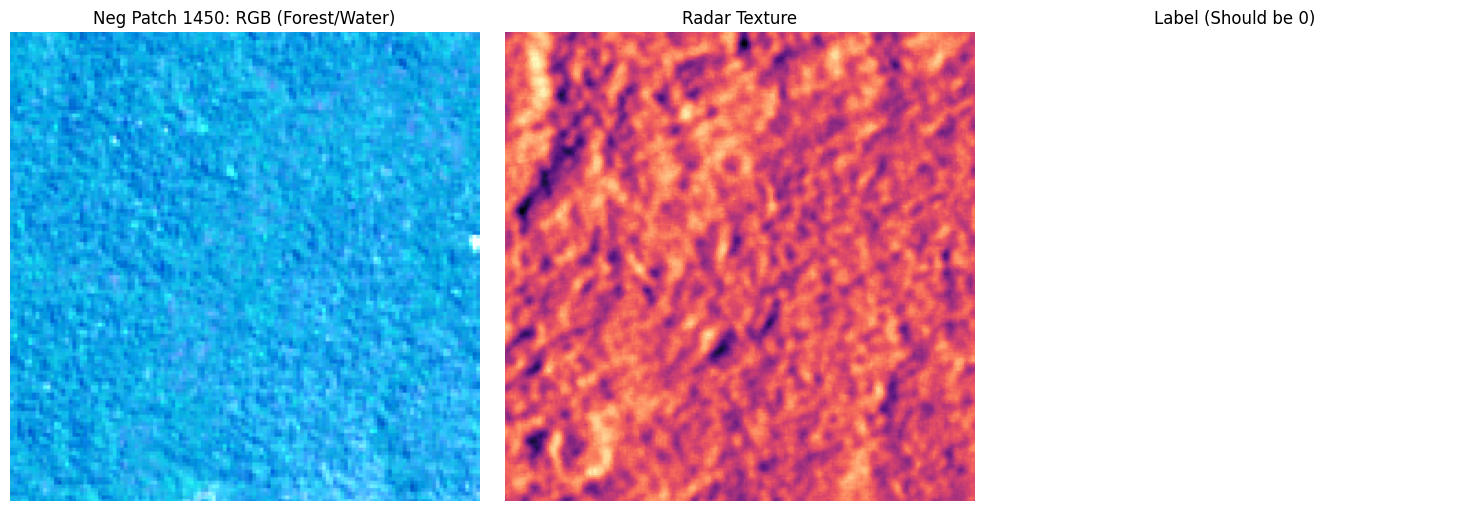

Negative Patch 1451 not found yet. It might still be processing in GEE.
Negative Patch 1452 not found yet. It might still be processing in GEE.
Negative Patch 1453 not found yet. It might still be processing in GEE.


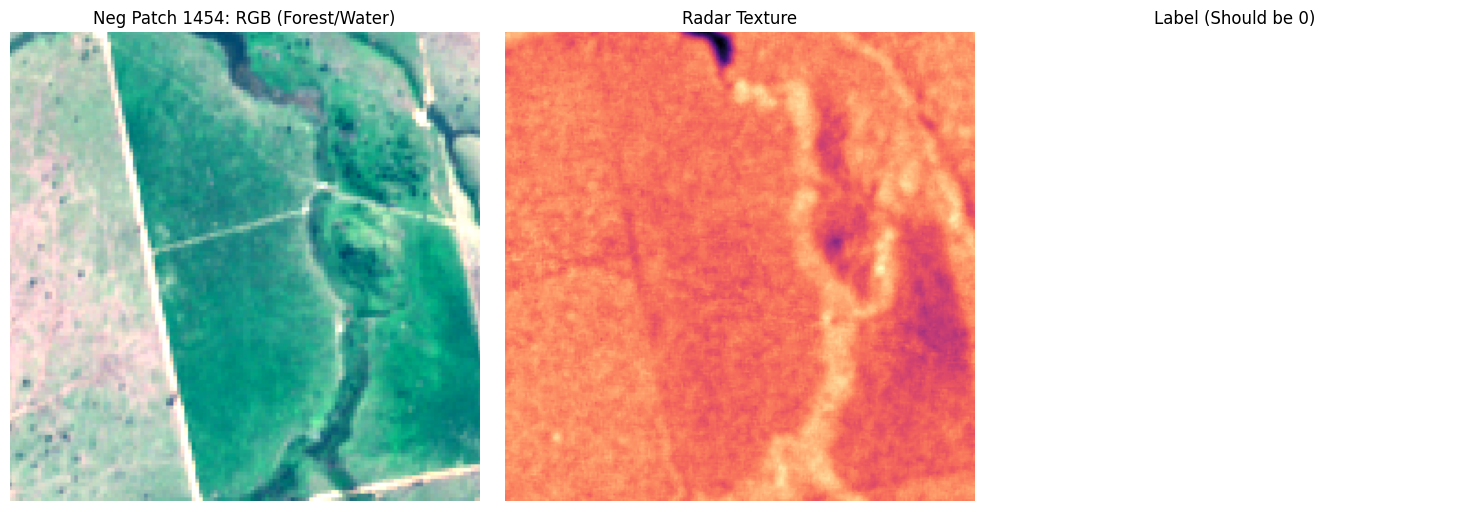

In [3]:
# =============================================================================
# 6: NEGATIVE PATCH AUDIT: VISUAL VERIFICATION OF NON-MINING SAMPLES
# =============================================================================
#
# WARNING: This notebook is for educational purposes only.
# Running it will attempt to mount YOUR Google Drive, not the author's.
#
# PURPOSE:
# This cell performs a quality assurance (QA) audit on the negative (non-mining)
# training patches. It visualizes the land-cover features to ensure the
# "Land-Only Gatekeeper" effectively prioritized terrestrial forest over
# open water and that the binary labels are correctly set to zero.
#
# KEY OPERATIONS:
#   - Parse Float32 TFRecords for the negative class (B2, B3, B4, VV, VH, Label).
#   - Reconstruct Sentinel-2 RGB composites with a 2/98 percentile stretch
#     optimized for forest and water contrast.
#   - Display Sentinel-1 Radar (VV) to inspect canopy texture and signal noise.
#   - Verify the 'Label' mask remains zero (black) across the entire 256x256 patch.
#
# This directly supports:
#   - Capstone Objective: Develop and apply a CNN-based computer-vision model in GEE
#   - Hypothesis H1: Achieve 80–90% overall accuracy in identifying mining deforestation
#
# GOAL:
# Confirm that the negative dataset provides a clean "baseline" of undisturbed
# land cover. This ensures the U-Net does not learn to associate water or
# sensor artifacts with the "background" class.
#
# IMPORTANT EDUCATIONAL DISCLAIMERS:
# - This code is developed strictly for academic purposes as part of the Master of Science
#   in Geographic Information Systems (GIS) Capstone project (430.800) at Johns Hopkins University.
# - All models, code, and results are for educational, research, and demonstration purposes only.
# - This work is NOT intended for operational use, law enforcement, or real-world decision-making.
# - Outputs should not be used to identify or accuse any specific illegal activities without
#   proper authorization and coordination with Brazilian authorities.
# - Users must comply with all data provider terms (ESA Sentinel data) and local regulations.
# - The model and results are provided "as-is" with no warranty for any purpose beyond academic study.
#
# AI DISCLOSURE:
# AI was used to augment this visualization script, specifically in the
# implementation of the dynamic contrast stretching and the error-handling
# logic for processing Earth Engine-exported GZIP TFRecords.
#
# Author: ATD
# Program: Johns Hopkins University - MS in Geographic Information Systems
# Capstone Course: 430.800
# Date: April 2026
# =============================================================================

import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Configuration
neg_dir = '/content/drive/MyDrive/Mining_Auto_NEGATIVES_5m_v1'
# Adjust this range to see more or fewer (e.g., range(0, 10))
batch_to_view = range(1450, 1455)

# Schema for the Negative run (All Floats)
neg_features = {
    'B2': tf.io.FixedLenSequenceFeature([], tf.float32, allow_missing=True),
    'B3': tf.io.FixedLenSequenceFeature([], tf.float32, allow_missing=True),
    'B4': tf.io.FixedLenSequenceFeature([], tf.float32, allow_missing=True),
    'VV': tf.io.FixedLenSequenceFeature([], tf.float32, allow_missing=True),
    'VH': tf.io.FixedLenSequenceFeature([], tf.float32, allow_missing=True),
    'label': tf.io.FixedLenSequenceFeature([], tf.float32, allow_missing=True),
}

def audit_negatives(indices):
    for idx in indices:
        file_path = os.path.join(neg_dir, f'Auto_Neg_Patch_{idx}-00000.tfrecord.gz')

        if not os.path.exists(file_path):
            print(f"Negative Patch {idx} not found yet. It might still be processing in GEE.")
            continue

        dataset = tf.data.TFRecordDataset(file_path, compression_type='GZIP')
        for raw_record in dataset.take(1):
            try:
                ex = tf.io.parse_single_example(raw_record, neg_features)

                # 1. RGB Processing (S2)
                r = ex['B4'].numpy().reshape(256, 256)
                g = ex['B3'].numpy().reshape(256, 256)
                b = ex['B2'].numpy().reshape(256, 256)
                rgb = np.stack([r, g, b], axis=-1)

                # Dynamic stretch for better forest/water contrast
                p2, p98 = np.percentile(rgb, (2, 98))
                rgb_norm = np.clip((rgb - p2) / (p98 - p2 + 1e-8), 0, 1)

                # 2. Radar Processing (VV)
                vv = ex['VV'].numpy().reshape(256, 256)

                # 3. Label Processing (Should be all zeros/black)
                mask = ex['label'].numpy().reshape(256, 256)

                # Visualize
                fig, ax = plt.subplots(1, 3, figsize=(15, 5))

                ax[0].imshow(rgb_norm)
                ax[0].set_title(f"Neg Patch {idx}: RGB (Forest/Water)")

                ax[1].imshow(vv, cmap='magma')
                ax[1].set_title("Radar Texture")

                ax[2].imshow(mask, vmin=0, vmax=1, cmap='Greys')
                ax[2].set_title("Label (Should be 0)")

                for a in ax: a.axis('off')
                plt.tight_layout()
                plt.show()

            except Exception as e:
                print(f"Error parsing Negative Patch {idx}: {e}")

# Run the audit
print("Starting audit of negative high-res patches...")
audit_negatives(batch_to_view)

In [7]:
# =============================================================================
# 5: AUTOMATED DATA CLEANING & QUARANTINE (NEGATIVE SAMPLES)
# =============================================================================
#
# WARNING: This notebook is for educational purposes only.
# Running it will attempt to mount YOUR Google Drive, not the author's.
#
# PURPOSE:
# This cell implements a specialized scrubbing routine for the negative
# (non-mining) dataset. It is designed as a "Hybrid Cleaner" capable of
# processing patches from different export iterations that may use varying
# data types (Float32 vs. Int64).
#
# KEY OPERATIONS:
#   - Detect and quarantine "Black Squares" caused by orbital gaps or sensor
#     processing errors in both Optical (B2) and Radar (VV) bands.
#   - Utilize a multi-dtype parsing strategy to handle hybrid batches
#     (Original samples vs. CleanBatch iterations).
#   - Synchronized File Management: When a bad patch is identified, both the
#     .tfrecord.gz binary and its matching .json metadata are moved to
#     quarantine to maintain dataset pair integrity.
#
# This directly supports:
#   - Capstone Objective: Develop and apply a CNN-based computer-vision model in GEE
#   - Hypothesis H1: Achieve 80–90% overall accuracy in identifying mining deforestation
#
# GOAL:
# Purify the "Background" class for the CNN. By removing null-data patches
# from the negative pool, the model avoids learning false associations
# between sensor "No Data" zones and undisturbed forest.
#
# IMPORTANT EDUCATIONAL DISCLAIMERS:
# - This code is developed strictly for academic purposes as part of the Master of Science
#   in Geographic Information Systems (GIS) Capstone project (430.800) at Johns Hopkins University.
# - All models, code, and results are for educational, research, and demonstration purposes only.
# - This work is NOT intended for operational use, law enforcement, or real-world decision-making.
# - Outputs should not be used to identify or accuse any specific illegal activities without
#   proper authorization and coordination with Brazilian authorities.
# - Users must comply with all data provider terms (ESA Sentinel data) and local regulations.
# - The model and results are provided "as-is" with no warranty for any purpose beyond academic study.
#
# AI DISCLOSURE:
# AI was used to augment the development of this hybrid scrubbing logic,
# specifically in designing the dual-dtype exception handling and the
# synchronized metadata-cleanup routine for Google Drive.
#
# Author: ATD
# Program: Johns Hopkins University - MS in Geographic Information Systems
# Capstone Course: 430.800
# Date: April 2026
# =============================================================================

import os
import tensorflow as tf
import shutil
from google.colab import drive

# 1. MOUNT DRIVE
drive.mount('/content/drive', force_remount=True)

# --- SETTINGS ---
# This path covers all files regardless of naming (Auto_Neg_ or CleanBatch_)
NEG_SOURCE_DIR = '/content/drive/MyDrive/Mining_Auto_NEGATIVES_5m_v1'
QUARANTINE_DIR = os.path.join(NEG_SOURCE_DIR, 'quarantine_bad_data')

if not os.path.exists(QUARANTINE_DIR):
    os.makedirs(QUARANTINE_DIR)

def is_actually_black_hybrid(file_path):
    """Detects black squares/holes while supporting both float32 and int64."""
    try:
        raw_dataset = tf.data.TFRecordDataset(file_path, compression_type='GZIP')
        for raw_record in raw_dataset.take(1):
            # Attempt parsing for both types to handle the hybrid batch (Original vs CleanBatch)
            for dtype in [tf.float32, tf.int64]:
                try:
                    feature_description = {
                        'B2': tf.io.FixedLenSequenceFeature([], dtype, allow_missing=True),
                        'VV': tf.io.FixedLenSequenceFeature([], dtype, allow_missing=True),
                    }
                    example = tf.io.parse_single_example(raw_record, feature_description)

                    # Cast to float for the mathematical zero-check
                    vv_data = tf.cast(example['VV'], tf.float32).numpy()
                    b2_data = tf.cast(example['B2'], tf.float32).numpy()

                    # Check Radar (Detects holes/texture loss)
                    if len(vv_data) > 0 and vv_data.max() == 0:
                        return True, "Black Radar (VV)"

                    # Check RGB (Detects black optical patches)
                    if len(b2_data) > 0 and b2_data.max() == 0:
                        return True, "Black Optical (B2)"

                    return False, "Clean"
                except:
                    continue # Try the next dtype if parsing fails
        return False, "Skip"
    except:
        return False, "Format/Read Error"

# --- EXECUTE SCRUB ---
if not os.path.exists(NEG_SOURCE_DIR):
    print(f"❌ Error: {NEG_SOURCE_DIR} not found. Check your Drive path.")
else:
    # We step through EVERY .tfrecord.gz file regardless of naming convention
    files = [f for f in os.listdir(NEG_SOURCE_DIR) if f.endswith('.tfrecord.gz')]
    print(f"🧐 Scanning {len(files)} NEGATIVE files for confirmed black squares...")

    count = 0
    for filename in files:
        path = os.path.join(NEG_SOURCE_DIR, filename)
        is_bad, reason = is_actually_black_hybrid(path)

        if is_bad:
            print(f"🚫 Quarantining {filename}: {reason}")

            # A. Move the TFRecord Patch
            shutil.move(path, os.path.join(QUARANTINE_DIR, filename))

            # B. Move the matching JSON Metadata (essential for keeping pairs together)
            json_file = filename.replace('.tfrecord.gz', '.json')
            json_path = os.path.join(NEG_SOURCE_DIR, json_file)
            if os.path.exists(json_path):
                shutil.move(json_path, os.path.join(QUARANTINE_DIR, json_file))

            count += 1

    print(f"\n--- SCRUB COMPLETE ---")
    print(f"📁 Moved {count} bad negative patches and their JSONs to {QUARANTINE_DIR}")
    print(f"✅ Clean negatives remain in the main folder for CNN training.")

Mounted at /content/drive
🧐 Scanning 809 NEGATIVE files for confirmed black squares...
🚫 Quarantining Auto_Neg_Patch_750-00000.tfrecord.gz: Black Radar (VV)
🚫 Quarantining Auto_Neg_Patch_772-00000.tfrecord.gz: Black Radar (VV)
🚫 Quarantining Auto_Neg_Patch_808-00000.tfrecord.gz: Black Radar (VV)
🚫 Quarantining Auto_Neg_Patch_822-00000.tfrecord.gz: Black Radar (VV)
🚫 Quarantining Auto_Neg_Patch_837-00000.tfrecord.gz: Black Radar (VV)
🚫 Quarantining Auto_Neg_Patch_870-00000.tfrecord.gz: Black Radar (VV)
🚫 Quarantining Auto_Neg_Patch_871-00000.tfrecord.gz: Black Radar (VV)
🚫 Quarantining Auto_Neg_Patch_907-00000.tfrecord.gz: Black Radar (VV)
🚫 Quarantining Auto_Neg_Patch_908-00000.tfrecord.gz: Black Radar (VV)
🚫 Quarantining Auto_Neg_Patch_911-00000.tfrecord.gz: Black Radar (VV)
🚫 Quarantining Auto_Neg_Patch_938-00000.tfrecord.gz: Black Radar (VV)
🚫 Quarantining Auto_Neg_Patch_954-00000.tfrecord.gz: Black Radar (VV)
🚫 Quarantining Auto_Neg_Patch_957-00000.tfrecord.gz: Black Radar (VV)
🚫 Q

In [4]:
# =============================================================================
# 7: DATASET INVENTORY & DISK USAGE AUDIT
# =============================================================================
#
# WARNING: This notebook is for educational purposes only.
# Running it will attempt to mount YOUR Google Drive, not the author's.
#
# PURPOSE:
# This cell provides a high-level summary of the accumulated training data.
# It serves as a final "Pre-Flight Check" to verify that the Earth Engine
# export tasks have completed successfully and that the files are properly
# indexed within the Google Drive environment.
#
# KEY OPERATIONS:
#   - Force-remount Google Drive to clear the file system cache and ensure
#     newly exported patches from GEE are visible.
#   - Calculate the total count of binary TFRecord patches for both Positive
#     (Mining) and Negative (Non-Mining) classes.
#   - Compute total disk utilization (MB) to monitor storage constraints.
#   - Identify the most recent file timestamp to confirm live-stream data
#     syncing between Earth Engine and the cloud environment.
#
# This directly supports:
#   - Capstone Objective: Develop and apply a CNN-based computer-vision model in GEE
#   - Hypothesis H1: Achieve 80–90% overall accuracy in identifying mining deforestation
#
# GOAL:
# Quantify the dataset scale and balance. Maintaining a balanced ratio
# between POS and NEG samples is critical for avoiding class bias during
# the backpropagation phase of CNN training.
#
# IMPORTANT EDUCATIONAL DISCLAIMERS:
# - This code is developed strictly for academic purposes as part of the Master of Science
#   in Geographic Information Systems (GIS) Capstone project (430.800) at Johns Hopkins University.
# - All models, code, and results are for educational, research, and demonstration purposes only.
# - This work is NOT intended for operational use, law enforcement, or real-world decision-making.
# - Outputs should not be used to identify or accuse any specific illegal activities without
#   proper authorization and coordination with Brazilian authorities.
# - Users must comply with all data provider terms (ESA Sentinel data) and local regulations.
# - The model and results are provided "as-is" with no warranty for any purpose beyond academic study.
#
# AI DISCLOSURE:
# AI was used to augment this auditing logic, specifically in the development
# of the file-system traversal functions and the dynamic formatting of
# the disk-usage telemetry.
#
# Author: ATD
# Program: Johns Hopkins University - MS in Geographic Information Systems
# Capstone Course: 430.800
# Date: April 2026
# =============================================================================
import os
from google.colab import drive

# 1. Force a refresh to see the latest GEE patches
drive.mount('/content/drive', force_remount=True)

# --- PATHS ---
POS_DIR = '/content/drive/MyDrive/Mining_Auto_Gold_5m_v1'
NEG_DIR = '/content/drive/MyDrive/Mining_Auto_NEGATIVES_5m_v1'

def check_folder_stats(directory, label):
    if not os.path.exists(directory):
        print(f"❌ {label}: Folder not found at {directory}")
        return

    # Gather all .tfrecord.gz files
    files = [os.path.join(directory, f) for f in os.listdir(directory) if f.endswith('.tfrecord.gz')]

    # Calculate total size in MB
    total_bytes = sum(os.path.getsize(f) for f in files)
    total_mb = total_bytes / (1024 * 1024)

    print(f"📊 {label} Stats:")
    print(f"   - Total Patches: {len(files)}")
    print(f"   - Total Disk Size: {total_mb:.2f} MB")

    if len(files) > 0:
        # Show the most recent file to confirm GEE is writing to the right place
        latest_file = max(files, key=os.path.getmtime)
        print(f"   - Latest Patch: {os.path.basename(latest_file)}")
    print("-" * 30)

# --- EXECUTE ---
check_folder_stats(POS_DIR, "POSITIVE (v1)")
check_folder_stats(NEG_DIR, "NEGATIVE (v1)")


Mounted at /content/drive
📊 POSITIVE (v1) Stats:
   - Total Patches: 870
   - Total Disk Size: 512.59 MB
   - Latest Patch: Auto_Gold_Patch_1199-00000.tfrecord.gz
------------------------------
📊 NEGATIVE (v1) Stats:
   - Total Patches: 881
   - Total Disk Size: 493.06 MB
   - Latest Patch: Auto_Neg_Patch_1473-00000.tfrecord.gz
------------------------------


In [18]:
# =============================================================================
# 8: DYNAMIC SPATIAL VALIDATION & QUALITY CONTROL MAP
# =============================================================================
#
# WARNING: This notebook is for educational purposes only.
# Running it will attempt to mount YOUR Google Drive, not the author's.
#
# PURPOSE:
# This cell generates an interactive geospatial visualization to validate the
# spatial distribution of the training dataset. It addresses a critical
# technical challenge: ensuring that patches exported across different UTM
# zones (common in the Brazilian Amazon) are correctly re-projected to
# WGS84 for accurate mapping.
#
# KEY OPERATIONS:
#   - Utilize 'pyproj' to dynamically detect and transform coordinates based
#     on the unique CRS (Coordinate Reference System) metadata in each JSON.
#   - Overlay 'MarkerClusters' for Positive (Green) and Negative (Black)
#     samples to allow for high-performance interaction with large datasets.
#   - Integrate the original Earth Engine 'Mining Polygons' (Red) to visually
#     confirm that Positive samples intersect ground-truth mining sites.
#
# This directly supports:
#   - Capstone Objective: Develop and apply a CNN-based computer-vision model in GEE
#   - Hypothesis H1: Achieve 80–90% overall accuracy in identifying mining deforestation
#
# GOAL:
# Detect and eliminate "spatial drift" or labeling errors. This visual audit
# is the final step in ensuring the CNN is trained on geographically
# accurate data before model execution begins.
#
# IMPORTANT EDUCATIONAL DISCLAIMERS:
# - This code is developed strictly for academic purposes as part of the Master of Science
#   in Geographic Information Systems (GIS) Capstone project (430.800) at Johns Hopkins University.
# - All models, code, and results are for educational, research, and demonstration purposes only.
# - This work is NOT intended for operational use, law enforcement, or real-world decision-making.
# - Outputs should not be used to identify or accuse any specific illegal activities without
#   proper authorization and coordination with Brazilian authorities.
# - Users must comply with all data provider terms (ESA Sentinel data) and local regulations.
# - The model and results are provided "as-is" with no warranty for any purpose beyond academic study.
#
# AI DISCLOSURE:
# AI was used to augment the development of this visualization logic,
# specifically in the implementation of the dynamic CRS transformation
# functions and the configuration of the Folium MarkerCluster interaction layers.
#
# Author: ATD
# Program: Johns Hopkins University - MS in Geographic Information Systems
# Capstone Course: 430.800
# Date: April 2026
# =============================================================================

import os
import json
import folium
from folium.plugins import MarkerCluster
from pyproj import Transformer
import ee

# Initialize Earth Engine
try:
    ee.Initialize(project='trusty-hub-437505-e5')
except Exception as e:
    print(f"Earth Engine Initialization failed: {e}")

# --- PATHS ---
POS_DIR = '/content/drive/MyDrive/Mining_Auto_Gold_5m_v1'
NEG_DIR = '/content/drive/MyDrive/Mining_Auto_NEGATIVES_5m_v1'
ASSET_ID = 'projects/trusty-hub-437505-e5/assets/mining_cumulative_2018_2024'

def get_lat_lon_dynamic(data):
    """Detects the CRS from the JSON and transforms accordingly."""
    # Get the EPSG code from the JSON metadata (e.g., 'EPSG:32718')
    crs_code = data['projection'].get('crs', 'EPSG:4326')
    matrix = data['projection']['affine']['doubleMatrix']

    # Create a transformer for this specific file's projection
    # matrix[2] = X (Easting), matrix[5] = Y (Northing)
    temp_transformer = Transformer.from_crs(crs_code, "EPSG:4326", always_xy=True)

    # Transform coordinates to WGS84 (Lat/Lon) for Leaflet mapping
    lon, lat = temp_transformer.transform(matrix[2] + 640, matrix[5] - 640)
    return lat, lon

def process_folder_dynamic(path, color, cluster_obj):
    """Parses JSON metadata files and adds them to the map cluster."""
    if not os.path.exists(path):
        print(f"Skipping: {path} not found.")
        return

    files = [f for f in os.listdir(path) if f.endswith('.json')]
    for f_name in files:
        try:
            with open(os.path.join(path, f_name), 'r') as j:
                data = json.load(j)
                lat, lon = get_lat_lon_dynamic(data)

                folium.CircleMarker(
                    location=[lat, lon],
                    radius=5, color=color, fill=True, fill_opacity=0.8,
                    popup=f_name
                ).add_to(cluster_obj)
        except Exception as e:
            continue

# --- BUILD MAP ---
# Centered on the Madre de Dios/Amazon Basin region
m = folium.Map(location=[-12.8, -70.0], zoom_start=8, tiles='OpenStreetMap')

# 1. Load Ground Truth Polygons (RED)
try:
    roi_poly = ee.FeatureCollection(ASSET_ID).geometry().simplify(100).getInfo()
    folium.GeoJson(roi_poly, name="Mining Polygons (Ground Truth)",
                   style_function=lambda x: {'color': 'red', 'weight': 2, 'fillOpacity': 0.2}).add_to(m)
except Exception as e:
    print("Could not overlay mining polygons.")

# 2. Initialize and Populate Clusters
pos_c = MarkerCluster(name="Green: Positive Samples (Mines)").add_to(m)
neg_c = MarkerCluster(name="Black: Negative Samples (Non-Mining)").add_to(m)

process_folder_dynamic(POS_DIR, '#2ecc71', pos_c) # Green
process_folder_dynamic(NEG_DIR, '#000000', neg_c) # Black

# 3. Final Map Layer Control
folium.LayerControl().add_to(m)

print("✅ Dynamic Validation Map Generated.")
display(m)


Output hidden; open in https://colab.research.google.com to view.